In [72]:
import numpy as np 
import matplotlib.pyplot as plt
import scienceplots
import os 
import re
import glob
from matplotlib import colormaps as cm
plt.style.use(['science','notebook','grid'])
%matplotlib inline

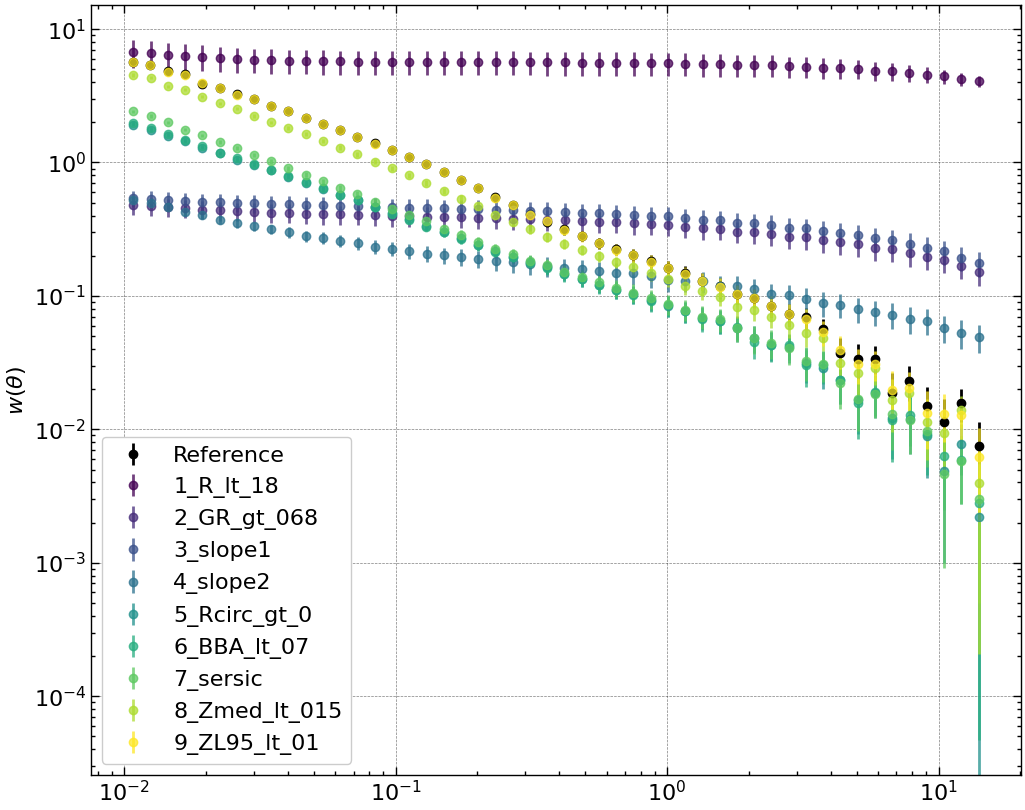

In [74]:
path = '/user/animesh.sah/FP_CUTS/data_cleaned_south_cumulative/w_theta_results'
w_ref = np.load('/user/animesh.sah/w_theta_results/treecorr_south_jackknife_patches_50_0.01_to_15_w_True_partial_percentile.npy')
plt.figure(figsize=(12,10))

colors = colors = plt.cm.viridis(np.linspace(0, 1, 9))

plt.errorbar(w_ref[0],w_ref[1], yerr = w_ref[2],ls='None',label='Reference',marker ='o',color='black')

for index,file in enumerate(np.sort(glob.glob(os.path.join(path,'*.npy')))):
    

    base = os.path.basename(file)

    if 'jackknife' in base:
        extracted = base.split("_True_")[-1].replace(".npy","")

        # if match: 
        #     name = match.group(1)

        theta_bins,w_theta, w_theta_err = np.load(file, allow_pickle=True)
        plt.errorbar(theta_bins,w_theta, yerr = w_theta_err,ls='None',label=extracted,marker ='o',color =colors[index],alpha =0.75)
plt.ylabel(r'$w(\theta)$')
plt.legend()
plt.xscale('log')
plt.yscale('log')

plt.show()


    

In [71]:
common_names

['2_GR_gt_068',
 '3_slope1',
 '4_slope2',
 '5_Rcirc_gt_0',
 '6_BBA_lt_07',
 '7_sersic',
 '8_Zmed_lt_015',
 '9_ZL95_lt_01']

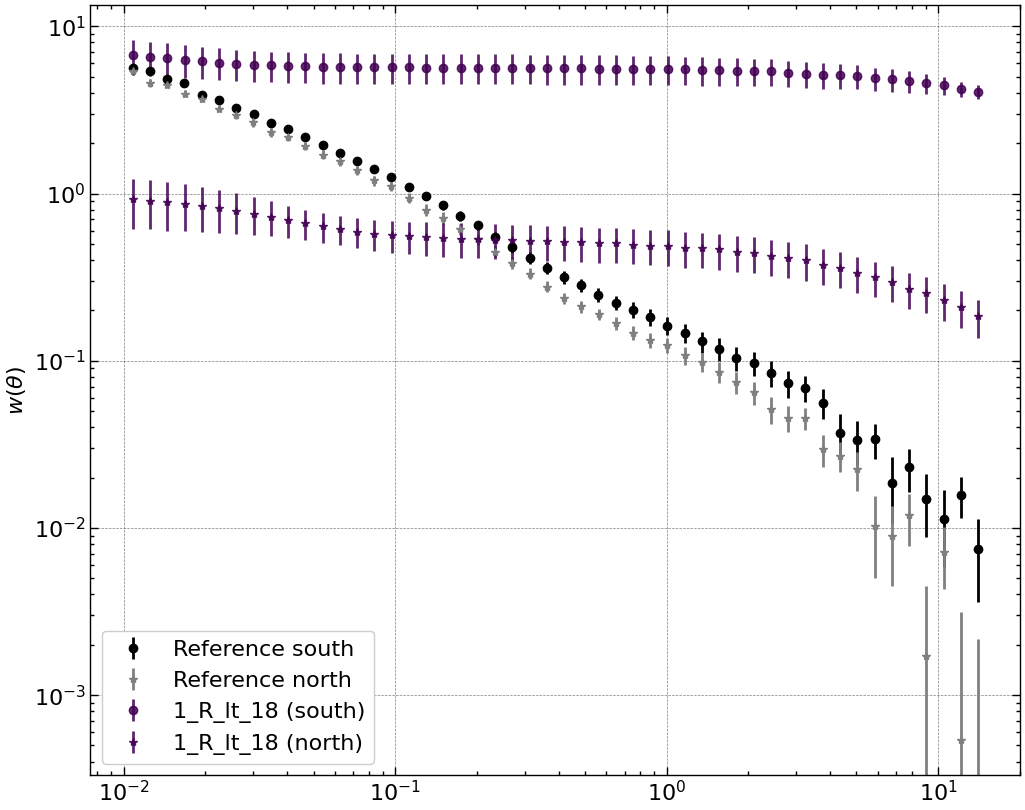

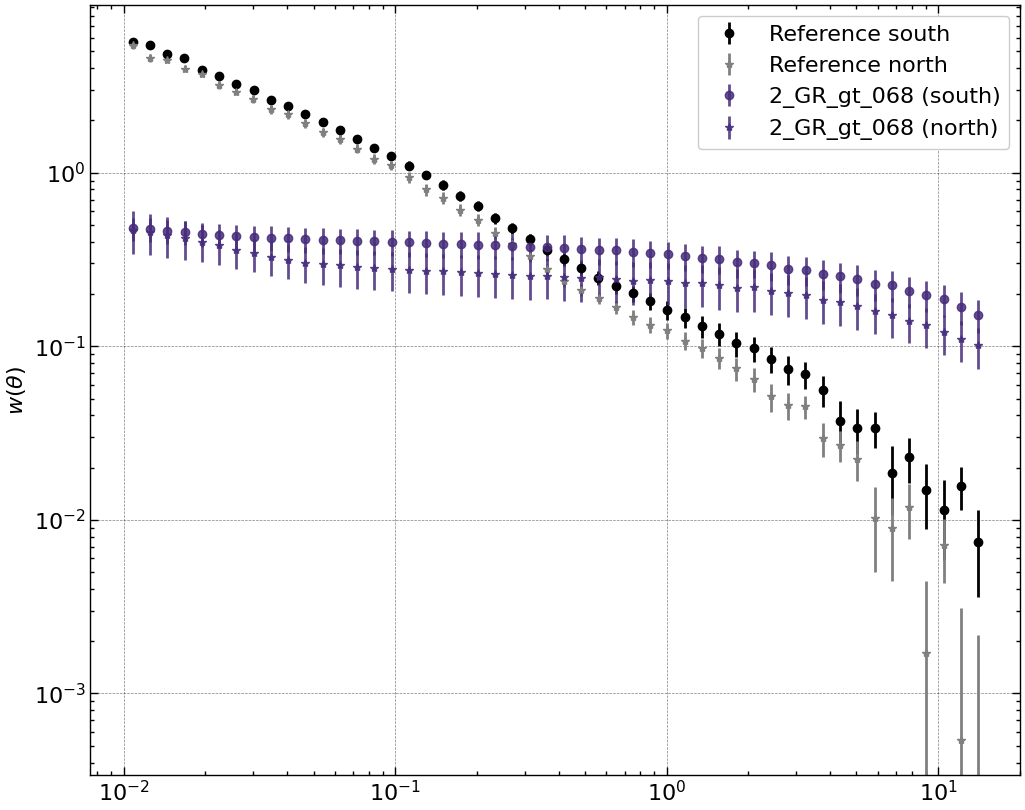

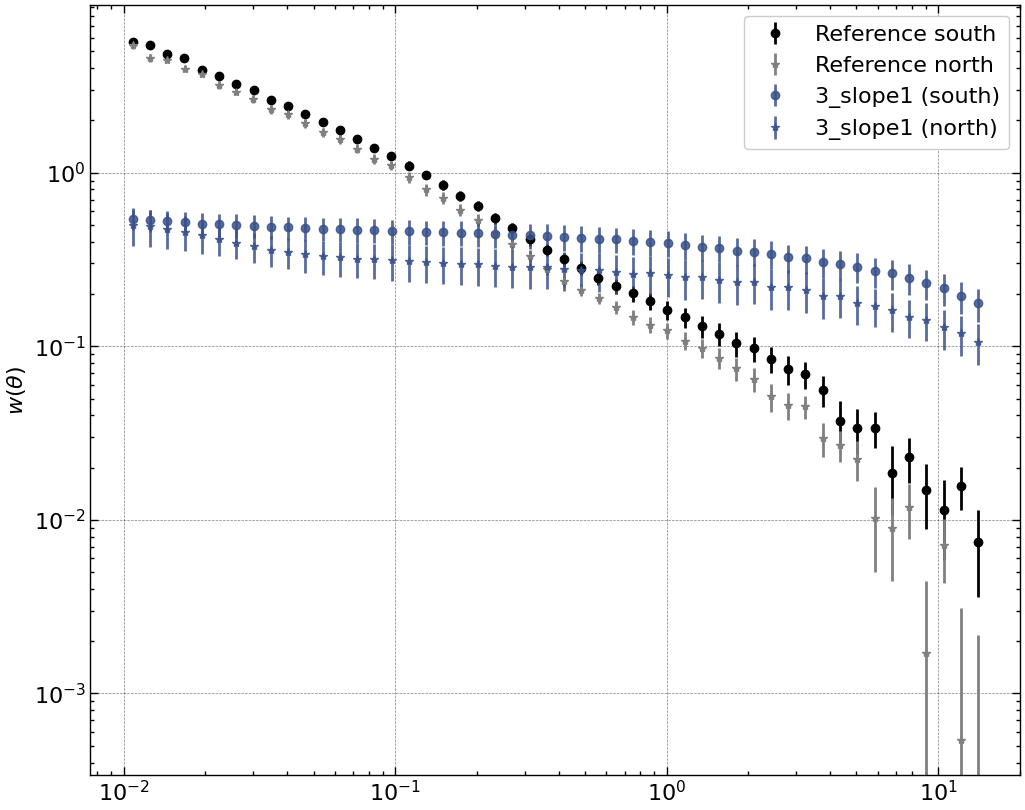

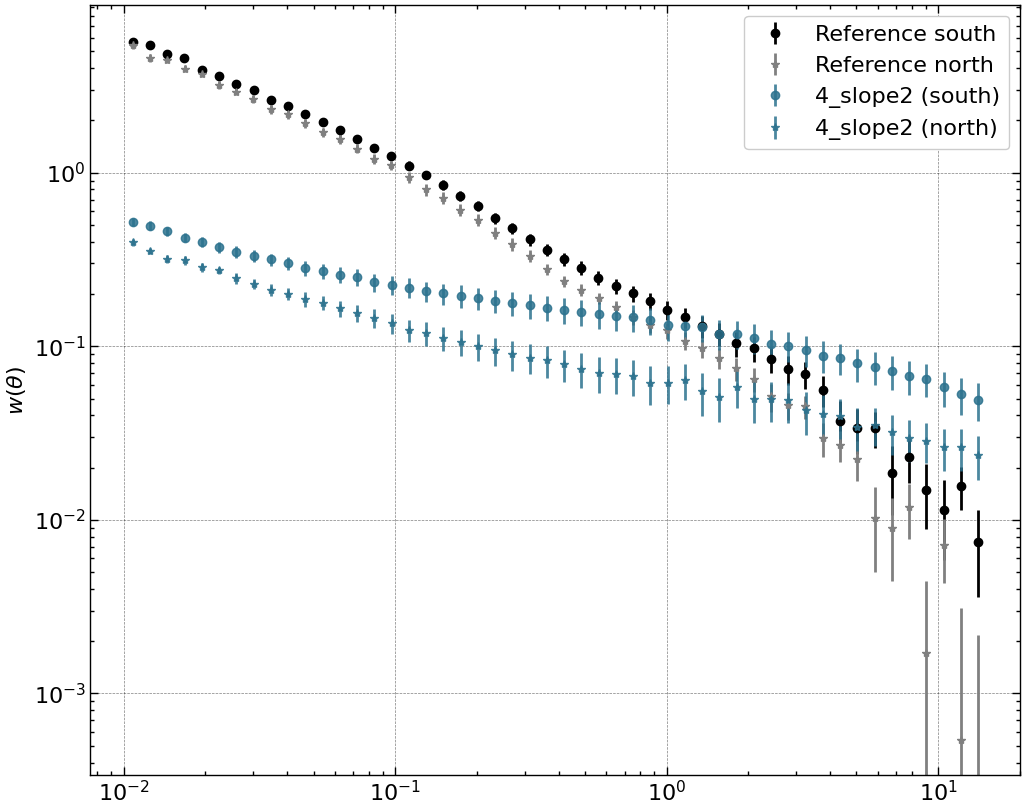

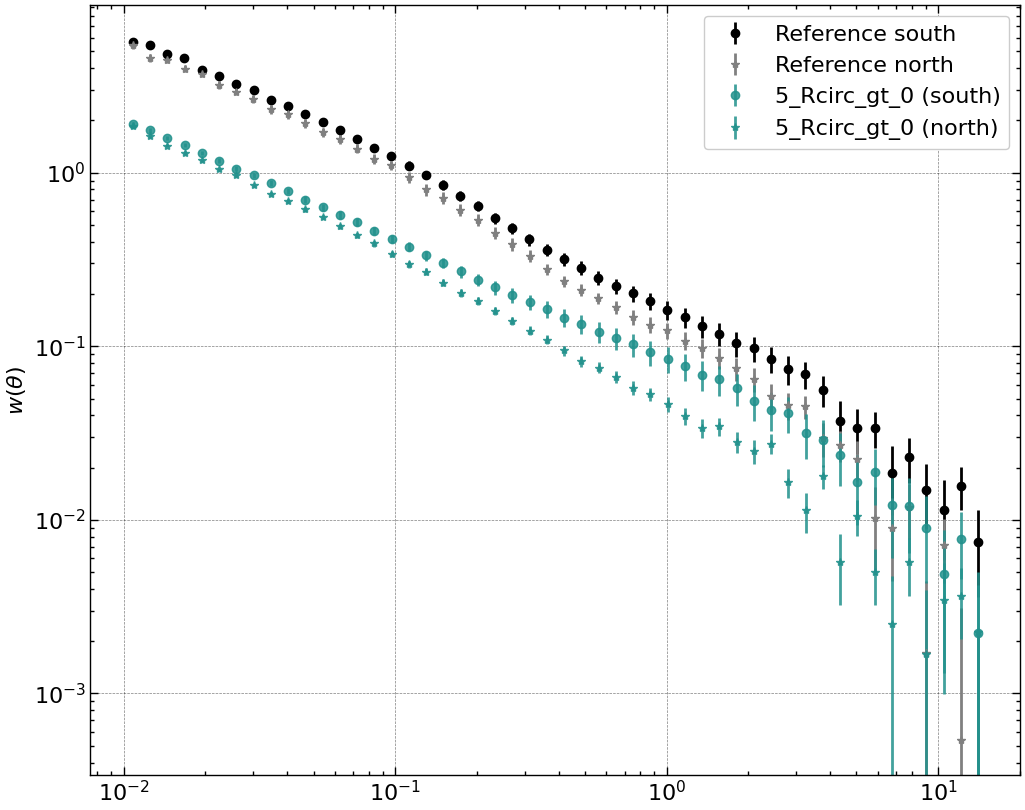

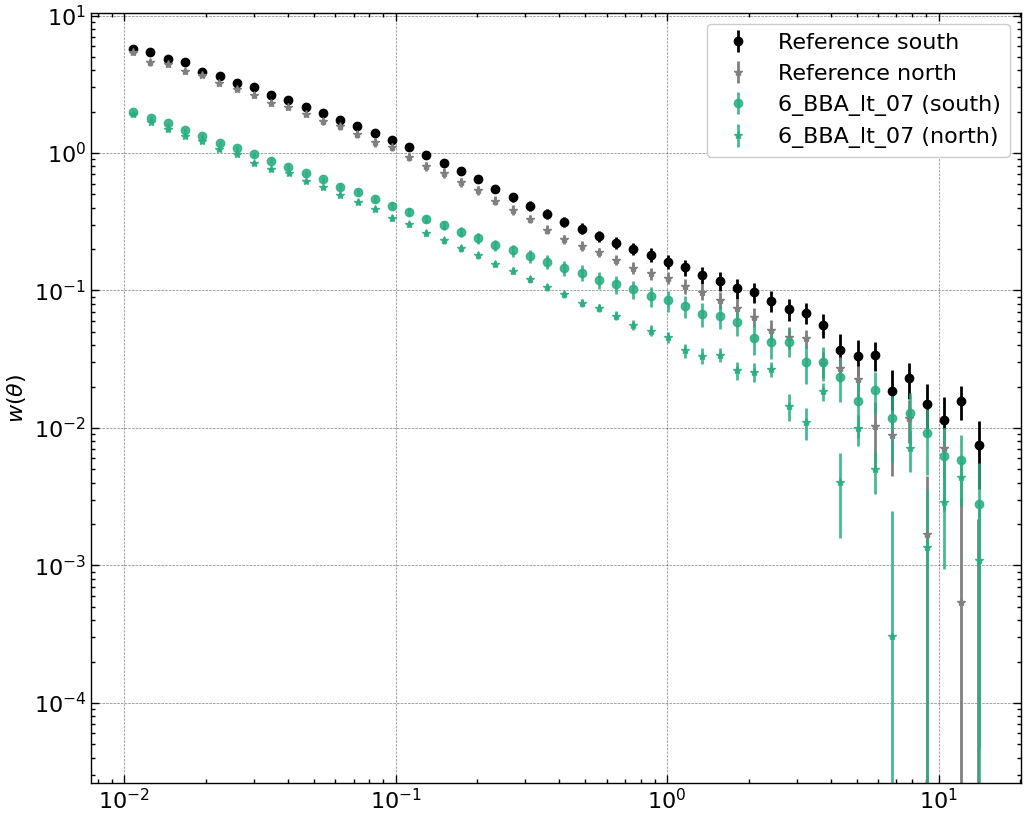

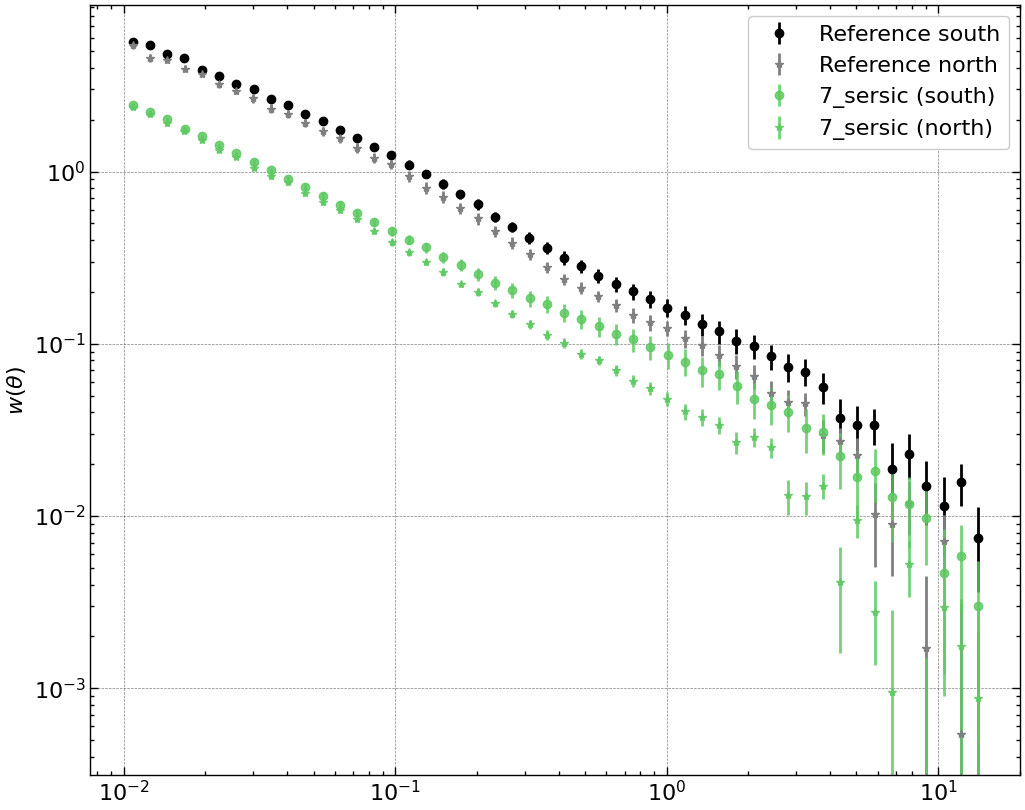

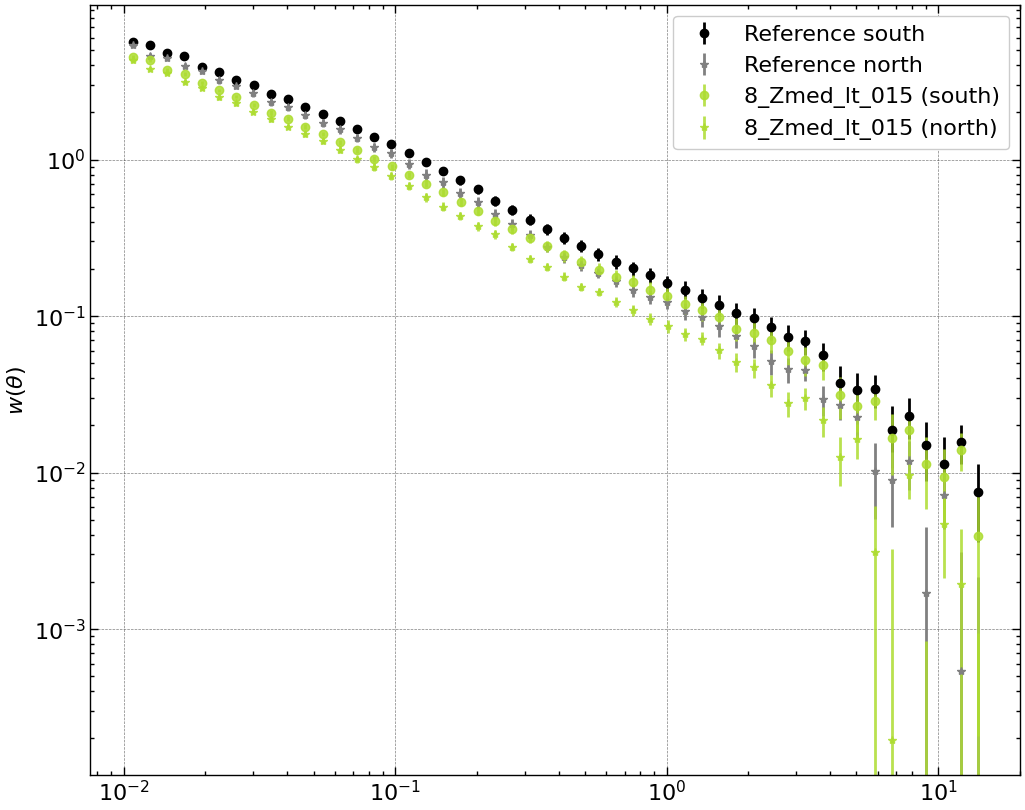

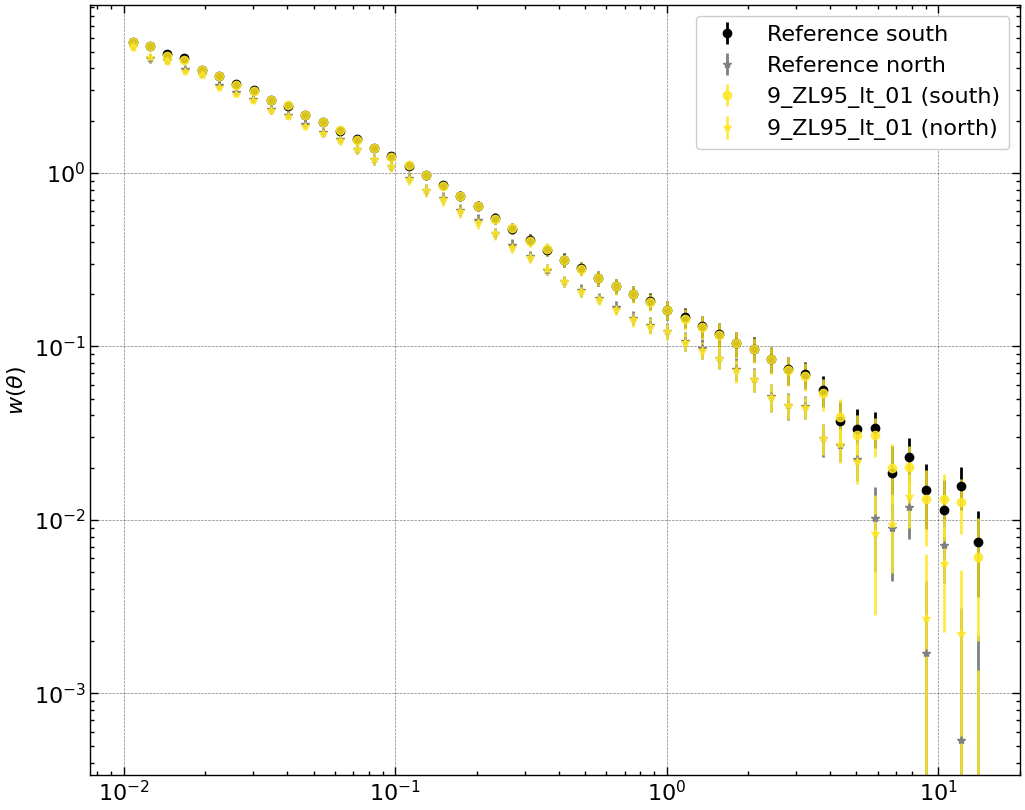

In [75]:
path_south = '/user/animesh.sah/FP_CUTS/data_cleaned_south_cumulative/w_theta_results'
path_north = '/user/animesh.sah/FP_CUTS/data_cleaned_north_cumulative/w_theta_results'
w_ref_south = np.load('/user/animesh.sah/w_theta_results/treecorr_south_jackknife_patches_50_0.01_to_15_w_True_partial_percentile.npy')
w_ref_north = np.load('/user/animesh.sah/w_theta_results/treecorr_north_jackknife_patches_50_0.01_to_15_w_True_partial_percentile.npy')

# Build maps: extracted_name -> file_path
south_map = {}
for f in np.sort(glob.glob(os.path.join(path_south, '*.npy'))):
    b = os.path.basename(f)
    if 'jackknife' in b:
        name = b.split("_True_")[-1].replace(".npy", "")
        south_map[name] = f

north_map = {}
for f in np.sort(glob.glob(os.path.join(path_north, '*.npy'))):
    b = os.path.basename(f)
    if 'jackknife' in b:
        name = b.split("_True_")[-1].replace(".npy", "")
        north_map[name] = f

# Only names present in both
common_names = sorted(set(south_map) & set(north_map))

for i, name in enumerate(common_names):
    color = colors[i % len(colors)]
    plt.figure(figsize=(12, 10))

    # reference curves
    plt.errorbar(w_ref_south[0], w_ref_south[1], yerr=w_ref_south[2],
                 ls='None', marker='o', color='black', label='Reference south')
    plt.errorbar(w_ref_north[0], w_ref_north[1], yerr=w_ref_north[2],
                 ls='None', marker='*', color='gray', label='Reference north')

    # same name from south and north
    theta_bins_s, w_theta_s, w_theta_err_s = np.load(south_map[name], allow_pickle=True)
    theta_bins_n, w_theta_n, w_theta_err_n = np.load(north_map[name], allow_pickle=True)

    plt.errorbar(theta_bins_s, w_theta_s, yerr=w_theta_err_s,
                 ls='None', marker='o', color=color, alpha=0.85, label=f'{name} (south)')
    plt.errorbar(theta_bins_n, w_theta_n, yerr=w_theta_err_n,
                 ls='None', marker='*', color=color, alpha=0.85, label=f'{name} (north)')

    plt.ylabel(r'$w(\theta)$')
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.show()